# Secom feature engineering(2) ~ Test

[Stage 1] 피처 엔지니어링 → 4개 데이터셋 추가 생성  
          - secom_fs_mi30/50/80/160 CSV    
          - datasets 딕셔너리에 통합 (총 5개)  
[Stage 2] 모델 실험 (5 데이터셋 × 4 모델 × 2 불균형처리 = 40개 조합)  
          - 모델 정의 (Flow A: SMOTEENN, Flow B: CostSensitive)  
          - CV 정의 (RepeatedStratifiedKFold 5×3)  
          - 평가지표: PR-AUC (방식B)  
[Stage 3] 결과 비교 → 상위 조합 Recall >0.7 threshold 탐색 
          - 최적 피처셋 × 모델 × 불균형처리 조합 식별  
[Stage 4] 최적 조합으로 하이퍼파라미터 튜닝  
[Stage 5] Test 셋 최종 평가 (1회)  

## Stage 1 : Feature Engineering 
[0] 데이터 로드 + y 변환  
[1] Mutual Information 점수 계산 (Train 기준)  
[2] MI 점수 시각화  
[3] top 30/50/80 데이터셋 생성 + CSV 저장  

In [ ]:
# [재시작 시 로드] 
import pandas as pd
import numpy as np
import joblib

# ── datasets 딕셔너리 재구성 ──────────────────────────────
def load_dataset(filepath):
    df = pd.read_csv(filepath)
    feature_cols = [c for c in df.columns if c not in ["Pass/Fail", "split"]]
    X_tr = df[df["split"] == "train"][feature_cols].values
    X_te = df[df["split"] == "test"][feature_cols].values
    y_tr = (df[df["split"] == "train"]["Pass/Fail"].values == 1).astype(int)
    y_te = (df[df["split"] == "test"]["Pass/Fail"].values == 1).astype(int)
    return X_tr, X_te, y_tr, y_te

datasets = {}
for name, path in {
    "base":     "secom_preprocessed.csv",
    "fs_mi30":  "secom_fs_mi30.csv",
    "fs_mi50":  "secom_fs_mi50.csv",
    "fs_mi80":  "secom_fs_mi80.csv",
    "fs_mi160": "secom_fs_mi160.csv",
}.items():
    X_tr, X_te, y_tr, y_te = load_dataset(path)
    datasets[name] = {"X_train": X_tr, "X_test": X_te, "y_train": y_tr, "y_test": y_te}

# ── Stage 결과 로드 ───────────────────────────────────────
results_df       = pd.read_csv("results_stage2.csv")
stage3_df        = joblib.load("results_stage3.pkl")
results_stage4_df = pd.read_csv("results_stage4.csv")
best_params      = joblib.load("best_params_stage4.pkl")

# Stage 5 완료 후 주석 해제
# best_rf = joblib.load("best_rf_stage5.pkl")
# best_th = joblib.load("best_threshold_stage5.pkl")

print("datasets:", list(datasets.keys()))
print("results_df:", results_df.shape)
print("stage3_df:", stage3_df.shape)
print("results_stage4_df:", results_stage4_df.shape)
print("best_params:", best_params)

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("secom_preprocessed.csv")

X_train = df[df["split"] == "train"].drop(columns=["Pass/Fail", "split"])
X_test  = df[df["split"] == "test"].drop(columns=["Pass/Fail", "split"])
y_train = df[df["split"] == "train"]["Pass/Fail"]
y_test  = df[df["split"] == "test"]["Pass/Fail"]

# -1(정상) → 0, 1(불량) → 1 변환
y_train = (y_train == 1).astype(int)
y_test  = (y_test == 1).astype(int)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Train 불량 비율: {y_train.mean():.3f}")
print(f"Test  불량 비율: {y_test.mean():.3f}")

X_train: (1253, 244), X_test: (314, 244)
Train 불량 비율: 0.066
Test  불량 비율: 0.067


### 1: Mutual Information 점수 계산

In [2]:
from sklearn.feature_selection import mutual_info_classif

# Data Leakage 방지: X_train, y_train 기준으로만 계산
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

mi_df = pd.DataFrame({
    "feature":  X_train.columns,
    "mi_score": mi_scores
}).sort_values("mi_score", ascending=False).reset_index(drop=True)

print("MI score 상위 10개:")
print(mi_df.head(10).to_string(index=False))
print(f"\nMI score == 0 인 피처 수: {(mi_df['mi_score'] == 0).sum()}")

MI score 상위 10개:
feature  mi_score
    541  0.028501
     84  0.025566
    130  0.024325
    443  0.024185
    128  0.023923
     91  0.022573
    412  0.021797
     70  0.021432
    103  0.021288
    331  0.020950

MI score == 0 인 피처 수: 84


### 2: MI 점수 시각화

C:\Users\jeiki\AppData\Local\Temp\ipykernel_24500\2478811280.py:12: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jeiki\AppData\Local\Temp\ipykernel_24500\2478811280.py:12: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jeiki\AppData\Local\Temp\ipykernel_24500\2478811280.py:12: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jeiki\AppData\Local\Temp\ipykernel_24500\2478811280.py:12: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jeiki\AppData\Local\Temp\ipykernel_24500\2478811280.py:12: UserWarning: Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jeiki\AppData\Local\Temp\ipykernel_24500\2478811280.py:12: UserWarning: Glyph 47548 (\N{HANGUL SYLLABLE RIM}) missing from 

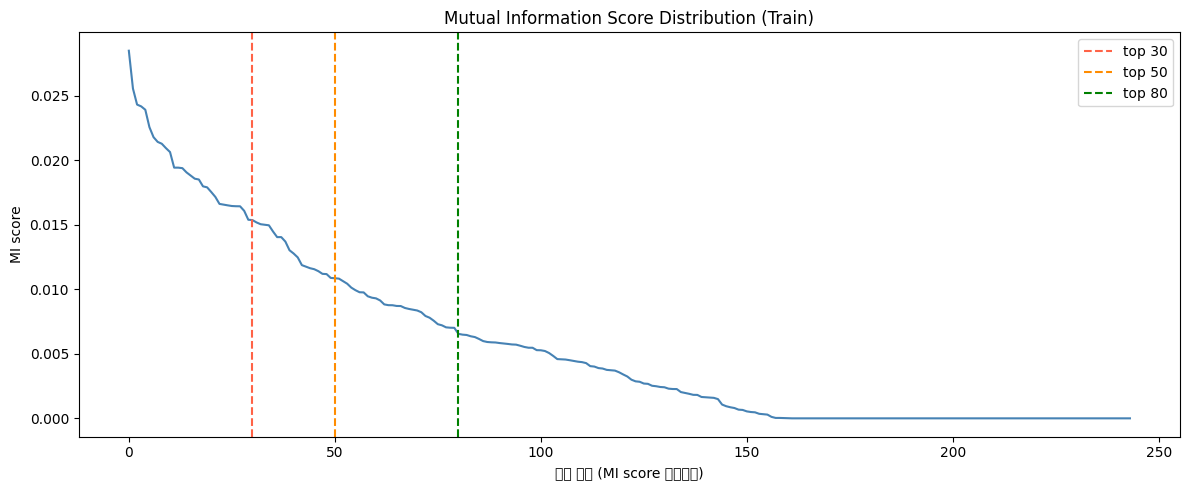

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(len(mi_df)), mi_df["mi_score"].values, color='steelblue')
ax.axvline(30, color='tomato',     linestyle='--', label='top 30')
ax.axvline(50, color='darkorange', linestyle='--', label='top 50')
ax.axvline(80, color='green',      linestyle='--', label='top 80')
ax.set_xlabel('피처 순위 (MI score 내림차순)')
ax.set_ylabel('MI score')
ax.set_title('Mutual Information Score Distribution (Train)')
ax.legend()
plt.tight_layout()
plt.show()

### 3: top 30/50/80 데이터셋 생성 + CSV 저장

In [4]:
top_ks = [30, 50, 80, 160]

for k in top_ks:
    # Train 기준 MI score 상위 k개 피처 선정
    selected_features = mi_df["feature"].head(k).tolist()

    # Train/Test에 동일한 피처 적용
    train_df = X_train[selected_features].copy()
    train_df["Pass/Fail"] = y_train.values
    train_df["split"]     = "train"

    test_df = X_test[selected_features].copy()
    test_df["Pass/Fail"] = y_test.values
    test_df["split"]     = "test"

    fs_df = pd.concat([train_df, test_df], axis=0)
    filename = f"secom_fs_mi{k}.csv"
    fs_df.to_csv(filename, index=False)

    print(f"{filename} 저장 완료 - shape: {fs_df.shape}")

secom_fs_mi30.csv 저장 완료 - shape: (1567, 32)
secom_fs_mi50.csv 저장 완료 - shape: (1567, 52)
secom_fs_mi80.csv 저장 완료 - shape: (1567, 82)
secom_fs_mi160.csv 저장 완료 - shape: (1567, 162)


In [5]:
for k in top_ks:
    filename = f"secom_fs_mi{k}.csv"
    tmp = pd.read_csv(filename)
    n_feat  = tmp.shape[1] - 2  # Pass/Fail, split 제외
    n_train = (tmp["split"] == "train").sum()
    n_test  = (tmp["split"] == "test").sum()
    print(f"{filename}: features={n_feat}, train={n_train}, test={n_test}")

secom_fs_mi30.csv: features=30, train=1253, test=314
secom_fs_mi50.csv: features=50, train=1253, test=314
secom_fs_mi80.csv: features=80, train=1253, test=314
secom_fs_mi160.csv: features=160, train=1253, test=314


In [6]:
# datasets 딕셔너리 구성 (base + FS 4개)

def load_dataset(filepath):
    """CSV → X_train, X_test, y_train, y_test 반환"""
    df = pd.read_csv(filepath)
    feature_cols = [c for c in df.columns if c not in ["Pass/Fail", "split"]]

    X_tr = df[df["split"] == "train"][feature_cols].values
    X_te = df[df["split"] == "test"][feature_cols].values
    y_tr = df[df["split"] == "train"]["Pass/Fail"].values
    y_te = df[df["split"] == "test"]["Pass/Fail"].values

    # -1/1 → 0/1 변환 (이미 0/1이면 영향 없음)
    y_tr = (y_tr == 1).astype(int)
    y_te = (y_te == 1).astype(int)
    return X_tr, X_te, y_tr, y_te

datasets = {}
files = {
    "base":     "secom_preprocessed.csv",
    "fs_mi30":  "secom_fs_mi30.csv",
    "fs_mi50":  "secom_fs_mi50.csv",
    "fs_mi80":  "secom_fs_mi80.csv",
    "fs_mi160": "secom_fs_mi160.csv",
}

for name, path in files.items():
    X_tr, X_te, y_tr, y_te = load_dataset(path)
    datasets[name] = {
        "X_train": X_tr, "X_test": X_te,
        "y_train": y_tr, "y_test": y_te,
    }
    print(f"{name:10s} | train: {X_tr.shape}, test: {X_te.shape} | 불량률: {y_tr.mean():.3f}")

base       | train: (1253, 244), test: (314, 244) | 불량률: 0.066
fs_mi30    | train: (1253, 30), test: (314, 30) | 불량률: 0.066
fs_mi50    | train: (1253, 50), test: (314, 50) | 불량률: 0.066
fs_mi80    | train: (1253, 80), test: (314, 80) | 불량률: 0.066
fs_mi160   | train: (1253, 160), test: (314, 160) | 불량률: 0.066


### [Stage 2] 모델 실험 

In [10]:
# Flow A: SMOTEENN (Pipeline으로 CV 내부 적용)
# Flow B: Cost-Sensitive (class_weight / scale_pos_weight)
# CV: RepeatedStratifiedKFold(5×3), 평가: PR-AUC

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ── CV 정의 ──────────────────────────────────────────────
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

# ── 불균형 비율 계산 (base 기준, 전체 동일) ────────────────
neg = (datasets["base"]["y_train"] == 0).sum()
pos = (datasets["base"]["y_train"] == 1).sum()
scale_pos = neg / pos  # XGB/LGBM용

# ── 모델 정의 함수 ────────────────────────────────────────
def get_models(flow):
    if flow == "A":
        return {
            "LR":   LogisticRegression(max_iter=1000, random_state=42),
            "RF":   RandomForestClassifier(random_state=42),
            "XGB":  XGBClassifier(tree_method="hist", device="cuda", eval_metric="logloss", random_state=42, verbosity=0),
            "LGBM": LGBMClassifier(device="gpu", random_state=42, verbose=-1),
        }
    else:
        return {
            "LR":   LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
            "RF":   RandomForestClassifier(class_weight="balanced", random_state=42),
            "XGB":  XGBClassifier(tree_method="hist", device="cuda", scale_pos_weight=scale_pos, eval_metric="logloss", random_state=42, verbosity=0),
            "LGBM": LGBMClassifier(device="gpu", class_weight="balanced", random_state=42, verbose=-1),
        }

# ── 실험 루프 ─────────────────────────────────────────────
results = []
total = len(datasets) * 4 * 2  # 40

with tqdm(total=total, desc="Stage 2 실험") as pbar:
    for ds_name, ds in datasets.items():
        X_tr, y_tr = ds["X_train"], ds["y_train"]

        for flow in ["A", "B"]:
            models = get_models(flow)

            for model_name, model in models.items():
                if flow == "A":
                    # SMOTEENN을 Pipeline 안에 넣어 fold마다 적용 (leakage 방지)
                    pipe = ImbPipeline([
                        ("smoteenn", SMOTEENN(random_state=42)),
                        ("clf",      model),
                    ])
                else:
                    pipe = model  # Cost-Sensitive는 그대로 사용

                scores = cross_val_score(
                    pipe, X_tr, y_tr,
                    cv=cv,
                    scoring="average_precision",  # PR-AUC
                    n_jobs=-1,
                )

                results.append({
                    "dataset":      ds_name,
                    "model":        model_name,
                    "flow":         flow,
                    "pr_auc_mean":  scores.mean(),
                    "pr_auc_std":   scores.std(),
                })

                pbar.set_postfix({
                    "ds": ds_name, "model": model_name, "flow": flow,
                    "pr_auc": f"{scores.mean():.4f}±{scores.std():.4f}"
                })
                pbar.update(1)

# ── 결과 정리 ─────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values("pr_auc_mean", ascending=False).reset_index(drop=True)
print("\n[Stage 2 결과 - PR-AUC 상위 10개]")
print(results_df.head(10).to_string(index=False))
# [저장] Stage 2 결과
results_df.to_csv("results_stage2.csv", index=False)
print("results_stage2.csv 저장 완료")

Stage 2 실험: 100%|██████████| 40/40 [04:26<00:00,  6.66s/it, ds=fs_mi160, model=LGBM, flow=B, pr_auc=0.1978±0.0582]


[Stage 2 결과 - PR-AUC 상위 10개]
 dataset model flow  pr_auc_mean  pr_auc_std
 fs_mi80  LGBM    B     0.208345    0.075883
fs_mi160   XGB    B     0.207165    0.064156
 fs_mi50  LGBM    B     0.206730    0.079008
 fs_mi30   XGB    B     0.198534    0.058797
fs_mi160  LGBM    B     0.197829    0.058171
 fs_mi50   XGB    B     0.189749    0.070037
 fs_mi30  LGBM    B     0.188420    0.055443
 fs_mi80   XGB    B     0.187248    0.069469
 fs_mi80   XGB    A     0.186984    0.085703
 fs_mi50    RF    B     0.181107    0.062085
results_stage2.csv 저장 완료


큰 그림:

Flow B (Cost-Sensitive)가 압도적 — 상위 9개가 전부 Flow B  
SMOTEENN(Flow A)은 fs_mi80 XGB 하나만 상위 10위 안에 진입  
base 데이터셋은 상위 10위에 없음 → MI 피처 선택이 효과 있음  

모델:

XGBoost, LightGBM이 상위 독점 → 트리 부스팅이 이 데이터에 적합  
RF도 fs_mi50에서 한 번 진입, LR은 상위권 없음  

피처셋:

fs_mi80이 1위, fs_mi160/fs_mi50이 혼재 → 30개는 너무 적고, 80~160 사이가 스윗스팟으로 보임  
명확한 최적 피처 수는 아직 불분명  

### [Stage 3] - threshold 탐색

In [11]:
# [Stage 3] 제약 조건부 threshold 탐색
# 제약: recall >= 0.70 / 목적: precision 최대화
# 상위 10개 조합 × threshold 그리드(0.01~0.50)
# 1순위: feasible=True (제약 만족) 먼저
# 2순위: precision 높은 순

from sklearn.metrics import fbeta_score, precision_score, recall_score

# ── 상위 10개 조합 추출 ───────────────────────────────────
top10 = results_df.head(10).reset_index(drop=True)

# ── threshold 그리드 ──────────────────────────────────────
thresholds = np.arange(0.01, 0.51, 0.01)

# ── 제약 조건 ─────────────────────────────────────────────
RECALL_MIN = 0.70

# ── CV 재사용 (Stage 2와 동일) ────────────────────────────
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

stage3_results = []

for _, row in tqdm(top10.iterrows(), total=len(top10), desc="Stage 3 threshold 탐색"):
    ds_name    = row["dataset"]
    model_name = row["model"]
    flow       = row["flow"]

    X_tr = datasets[ds_name]["X_train"]
    y_tr = datasets[ds_name]["y_train"]

    # 모델 및 파이프라인 구성
    models_dict = get_models(flow)
    model = models_dict[model_name]

    if flow == "A":
        pipe = ImbPipeline([
            ("smoteenn", SMOTEENN(random_state=42)),
            ("clf",      model),
        ])
    else:
        pipe = model

    # threshold별 fold 지표 수집
    th_prec_folds = {th: [] for th in thresholds}
    th_rec_folds  = {th: [] for th in thresholds}
    th_f2_folds   = {th: [] for th in thresholds}

    for train_idx, val_idx in cv.split(X_tr, y_tr):
        X_fold_tr, X_fold_val = X_tr[train_idx], X_tr[val_idx]
        y_fold_tr, y_fold_val = y_tr[train_idx], y_tr[val_idx]

        pipe.fit(X_fold_tr, y_fold_tr)
        proba = pipe.predict_proba(X_fold_val)[:, 1]

        for th in thresholds:
            y_pred = (proba >= th).astype(int)
            th_prec_folds[th].append(precision_score(y_fold_val, y_pred, zero_division=0))
            th_rec_folds[th].append(recall_score(y_fold_val, y_pred, zero_division=0))
            th_f2_folds[th].append(fbeta_score(y_fold_val, y_pred, beta=2, zero_division=0))

    # threshold별 평균 계산
    th_prec_mean = {th: np.mean(th_prec_folds[th]) for th in thresholds}
    th_rec_mean  = {th: np.mean(th_rec_folds[th])  for th in thresholds}
    th_f2_mean   = {th: np.mean(th_f2_folds[th])   for th in thresholds}

    # 제약 조건 만족하는 threshold 후보
    valid_ths = [th for th in thresholds if th_rec_mean[th] >= RECALL_MIN]

    if len(valid_ths) > 0:
        # 제약 만족 → 그중 precision 최대
        best_th = max(valid_ths, key=lambda th: th_prec_mean[th])
        feasible = True
    else:
        # 제약 불만족 → 가장 recall 높은 threshold (참고용)
        best_th = max(thresholds, key=lambda th: th_rec_mean[th])
        feasible = False

    stage3_results.append({
        "dataset":        ds_name,
        "model":          model_name,
        "flow":           flow,
        "feasible":       feasible,
        "best_threshold": round(best_th, 2),
        "precision":      np.mean(th_prec_folds[best_th]),
        "precision_std":  np.std(th_prec_folds[best_th]),
        "recall":         np.mean(th_rec_folds[best_th]),
        "recall_std":     np.std(th_rec_folds[best_th]),
        "f2":             np.mean(th_f2_folds[best_th]),
        # 시각화용 전체 곡선
        "th_prec_curve":  {round(th, 2): th_prec_mean[th] for th in thresholds},
        "th_rec_curve":   {round(th, 2): th_rec_mean[th]  for th in thresholds},
    })

# 정렬: feasible 우선 → precision 내림차순
stage3_df = (
    pd.DataFrame(stage3_results)
    .sort_values(["feasible", "precision"], ascending=[False, False])
    .reset_index(drop=True)
)

print(f"\n[Stage 3 결과 - recall >= {RECALL_MIN} 제약, precision 최대화]")
print(stage3_df[["dataset","model","flow","feasible","best_threshold",
                 "precision","precision_std","recall","recall_std","f2"]].to_string(index=False))

# [저장] Stage 3 결과
joblib.dump(stage3_df, "results_stage3.pkl")
print("results_stage3.pkl 저장 완료")

Stage 3 threshold 탐색: 100%|██████████| 10/10 [01:57<00:00, 11.72s/it]


[Stage 3 결과 - recall >= 0.7 제약, precision 최대화]
 dataset model flow  feasible  best_threshold  precision  precision_std   recall  recall_std       f2
 fs_mi50    RF    B      True            0.05   0.099106       0.012719 0.771324    0.078177 0.326724
 fs_mi80   XGB    A      True            0.05   0.095718       0.009875 0.711765    0.101662 0.310089
 fs_mi80  LGBM    B     False            0.01   0.178372       0.044243 0.401716    0.089999 0.319286
fs_mi160  LGBM    B     False            0.01   0.176415       0.040387 0.376471    0.091571 0.305034
 fs_mi50  LGBM    B     False            0.01   0.165533       0.045447 0.432108    0.088275 0.325625
fs_mi160   XGB    B     False            0.01   0.148976       0.024628 0.493382    0.075144 0.336023
 fs_mi30  LGBM    B     False            0.01   0.147156       0.034465 0.412500    0.103432 0.301502
 fs_mi50   XGB    B     False            0.01   0.138646       0.032384 0.500490    0.093374 0.327925
 fs_mi80   XGB    B     False     

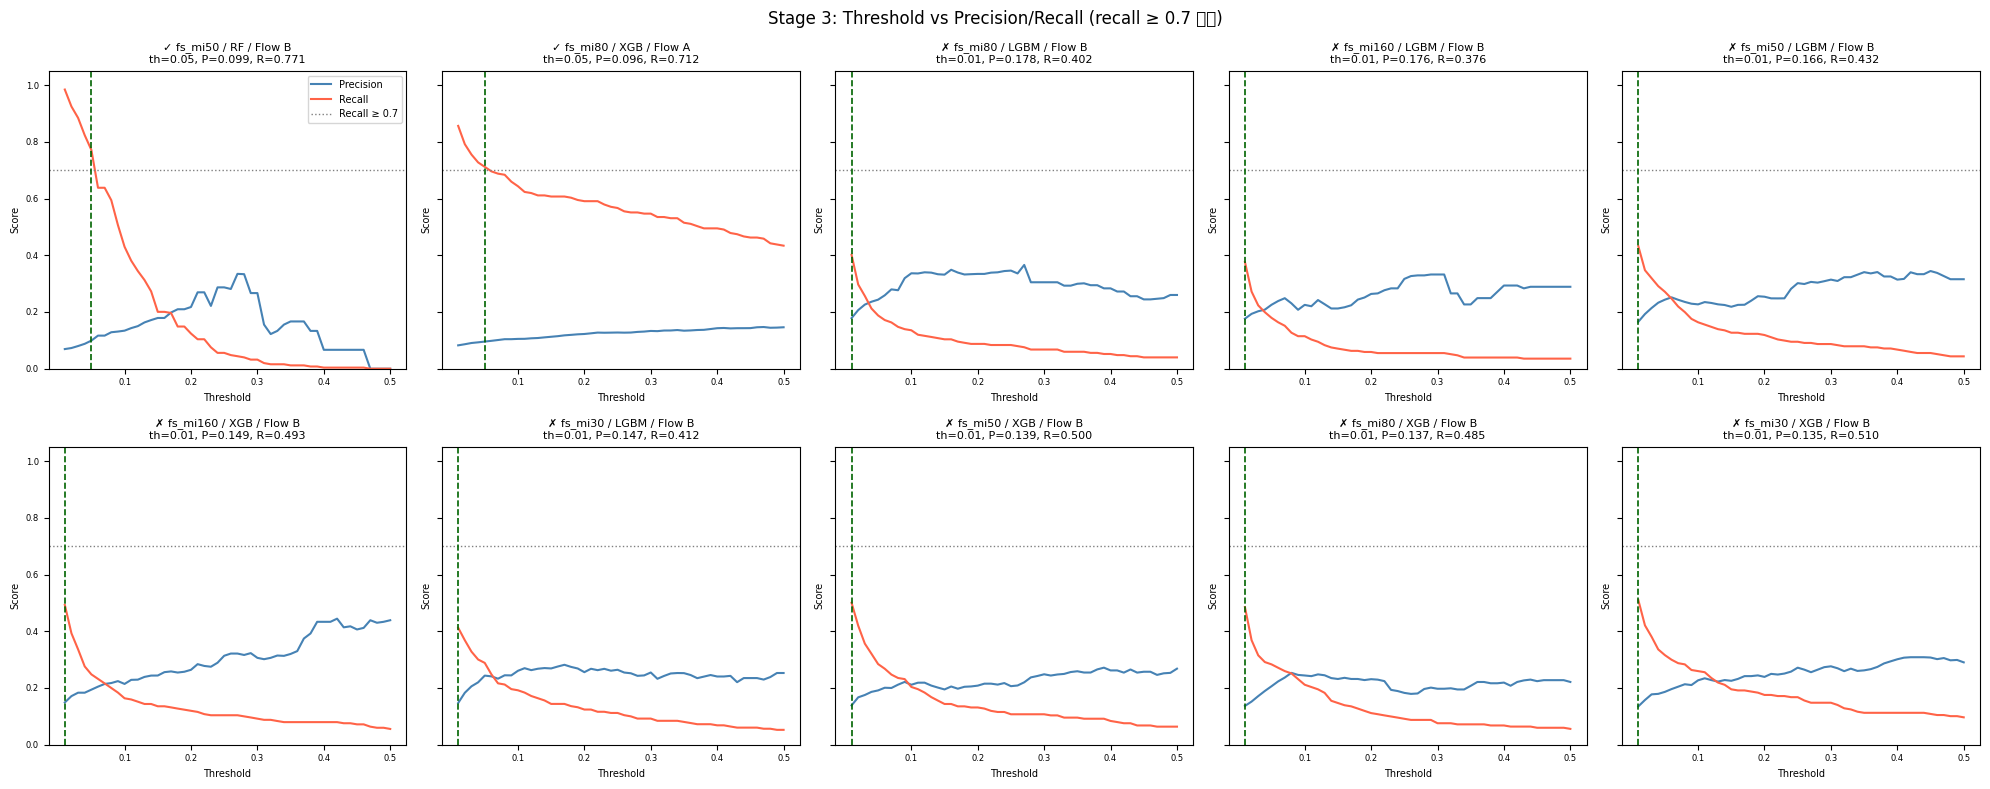

In [12]:
# [Stage 3] threshold vs precision/recall 곡선 (상위 10개)

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
axes = axes.flatten()

for i, row in stage3_df.iterrows():
    ax = axes[i]
    ths = list(row["th_prec_curve"].keys())
    prec = list(row["th_prec_curve"].values())
    rec  = list(row["th_rec_curve"].values())

    ax.plot(ths, prec, color='steelblue', label='Precision', linewidth=1.5)
    ax.plot(ths, rec,  color='tomato',    label='Recall',    linewidth=1.5)

    # 제약선 (recall >= 0.70)
    ax.axhline(RECALL_MIN, color='gray', linestyle=':', linewidth=1, label=f'Recall ≥ {RECALL_MIN}')

    # best threshold
    ax.axvline(row["best_threshold"], color='darkgreen', linestyle='--', linewidth=1.2)

    feas_mark = "✓" if row["feasible"] else "✗"
    ax.set_title(f"{feas_mark} {row['dataset']} / {row['model']} / Flow {row['flow']}\n"
                 f"th={row['best_threshold']:.2f}, P={row['precision']:.3f}, R={row['recall']:.3f}",
                 fontsize=8)
    ax.set_xlabel("Threshold", fontsize=7)
    ax.set_ylabel("Score", fontsize=7)
    ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.5])
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='both', labelsize=6)
    if i == 0:
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle(f"Stage 3: Threshold vs Precision/Recall (recall ≥ {RECALL_MIN} 제약)", fontsize=12)
plt.tight_layout()
plt.show()

### [Stage 4] : hyperparameter tuning

In [13]:
# [Stage 4] 하이퍼파라미터 튜닝 (proba 기반 custom scorer)
# scoring: predict_proba → threshold 탐색 → recall >= 0.70 만족 시 precision 최대값 반환
# CV: RepeatedStratifiedKFold(5×3), RandomizedSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import precision_score, recall_score, make_scorer
from sklearn.base import clone
from itertools import product
import random
from tqdm import tqdm

# ── 데이터 ────────────────────────────────────────────────
X_tr = datasets["fs_mi50"]["X_train"]
y_tr = datasets["fs_mi50"]["y_train"]

# ── 설정 ─────────────────────────────────────────────────
RECALL_MIN  = 0.70
THRESHOLDS  = np.arange(0.01, 0.51, 0.01)

# ── 파라미터 탐색 공간 ────────────────────────────────────
param_dist = {
    "n_estimators":     [100, 200, 300, 500],
    "max_depth":        [3, 5, 7, 10, 15, None],
    "min_samples_leaf": [1, 2, 4, 8, 16, 20],
    "max_features":     ["sqrt", "log2", 0.3, 0.5, 0.7],
}

# ── 파라미터 조합 샘플링 ──────────────────────────────────
rng = np.random.RandomState(42)
N_ITER = 50
random.seed(42)
param_list = random.sample(
    [
        {
            "n_estimators":     int(n),
            "max_depth":        None if d is None else int(d),
            "min_samples_leaf": int(m),
            "max_features":     f if isinstance(f, str) else float(f),
        }
        for n, d, m, f in product(
            param_dist["n_estimators"],
            param_dist["max_depth"],
            param_dist["min_samples_leaf"],
            param_dist["max_features"],
        )
    ],
    N_ITER,
)

# ── CV ───────────────────────────────────────────────────
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

# ── 수동 탐색 루프 (tqdm 진행바) ──────────────────────────
results_stage4 = []

for params in tqdm(param_list, desc="Stage 4 파라미터 탐색"):
    rf = RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        **params,
    )

    fold_best_precisions = []

    for train_idx, val_idx in cv.split(X_tr, y_tr):
        X_fold_tr, X_fold_val = X_tr[train_idx], X_tr[val_idx]
        y_fold_tr, y_fold_val = y_tr[train_idx], y_tr[val_idx]

        rf_fold = clone(rf)
        rf_fold.fit(X_fold_tr, y_fold_tr)
        proba = rf_fold.predict_proba(X_fold_val)[:, 1]

        # threshold 탐색: recall >= 0.70 만족 시 precision 최대화
        best_prec = 0.0
        for th in THRESHOLDS:
            y_pred = (proba >= th).astype(int)
            rec = recall_score(y_fold_val, y_pred, zero_division=0)
            if rec >= RECALL_MIN:
                prec = precision_score(y_fold_val, y_pred, zero_division=0)
                best_prec = max(best_prec, prec)

        fold_best_precisions.append(best_prec)

    results_stage4.append({
        "params":         params,
        "mean_score":     np.mean(fold_best_precisions),
        "std_score":      np.std(fold_best_precisions),
    })

# ── 결과 정리 ─────────────────────────────────────────────
results_stage4_df = (
    pd.DataFrame(results_stage4)
    .sort_values("mean_score", ascending=False)
    .reset_index(drop=True)
)

best = results_stage4_df.iloc[0]
print(f"\n최적 파라미터: {best['params']}")
print(f"CV score (constrained precision mean): {best['mean_score']:.4f} ± {best['std_score']:.4f}")

print(f"\n제약 만족 후보 수: {(results_stage4_df['mean_score'] > 0).sum()} / {N_ITER}")
print("\n[상위 10개 후보]")
print(results_stage4_df.head(10).to_string(index=False))

# [저장] Stage 4 결과
results_stage4_df.to_csv("results_stage4.csv", index=False)
best_params = results_stage4_df.iloc[0]["params"]
joblib.dump(best_params, "best_params_stage4.pkl")
print("results_stage4.csv 저장 완료")
print("best_params_stage4.pkl 저장 완료")

Stage 4 파라미터 탐색: 100%|██████████| 50/50 [06:37<00:00,  7.94s/it]


최적 파라미터: {'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt'}
CV score (constrained precision mean): 0.1386 ± 0.0499

제약 만족 후보 수: 50 / 50

[상위 10개 후보]
                                                                               params  mean_score  std_score
 {'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt'}    0.138601   0.049886
{'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt'}    0.138578   0.042751
{'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'}    0.138210   0.053903
    {'n_estimators': 300, 'max_depth': 7, 'min_samples_leaf': 4, 'max_features': 0.3}    0.137563   0.053273
    {'n_estimators': 300, 'max_depth': 7, 'min_samples_leaf': 2, 'max_features': 0.7}    0.136881   0.058005
 {'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 8, 'max_features': 'sqrt'}    0.136455   0.042365
 {'n_estimators': 200, 'max_depth': None, 'min_sample

### [Stage 5] : test 학습

OOF 기준 최적 threshold : 0.27
OOF precision           : 0.1107
OOF recall              : 0.7108

[Stage 5] 최종 Test 결과 (threshold=0.27)
  Precision       : 0.1019
  Recall          : 0.7619
  F1-score        : 0.1798
  F2-score        : 0.3320
  PR-AUC          : 0.1506

혼동 행렬:
  TN=152  FP=141
  FN=5  TP=16


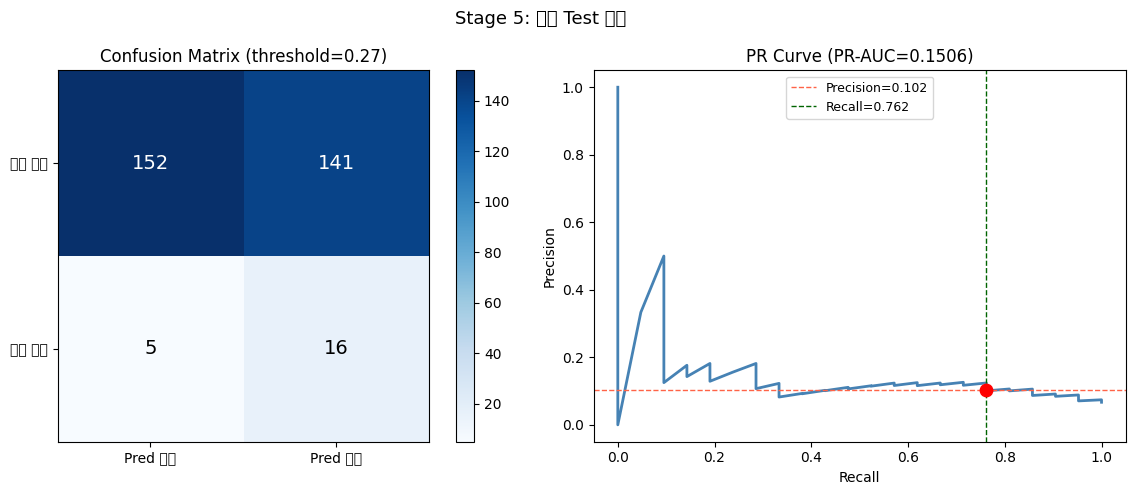

best_rf_stage5.pkl 저장 완료
best_threshold_stage5.pkl 저장 완료


In [14]:
# [Stage 5] Test 셋 최종 평가 (1회)
# (1) OOF predict_proba로 최적 threshold 결정
# (2) 전체 train으로 최종 모델 학습
# (3) test 셋 1회 평가

from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import (
    precision_score, recall_score, f1_score, fbeta_score,
    confusion_matrix, precision_recall_curve, average_precision_score
)
import matplotlib.gridspec as gridspec

# ── 데이터 ────────────────────────────────────────────────
X_tr = datasets["fs_mi50"]["X_train"]
y_tr = datasets["fs_mi50"]["y_train"]
X_te = datasets["fs_mi50"]["X_test"]
y_te = datasets["fs_mi50"]["y_test"]

# ── 최적 파라미터로 모델 정의 ─────────────────────────────
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=4,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

# ── (1) OOF proba로 최적 threshold 결정 ──────────────────
# RepeatedStratifiedKFold 대신 단순 StratifiedKFold 사용
# (cross_val_predict는 반복 CV 미지원)
oof_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba = cross_val_predict(
    best_rf, X_tr, y_tr,
    cv=oof_cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

# threshold 탐색: recall >= 0.70 만족 시 precision 최대화
THRESHOLDS  = np.arange(0.01, 0.51, 0.01)
RECALL_MIN  = 0.70

best_th      = None
best_prec_th = 0.0

for th in THRESHOLDS:
    y_pred_oof = (oof_proba >= th).astype(int)
    rec  = recall_score(y_tr, y_pred_oof, zero_division=0)
    prec = precision_score(y_tr, y_pred_oof, zero_division=0)
    if rec >= RECALL_MIN and prec > best_prec_th:
        best_prec_th = prec
        best_th      = th

print(f"OOF 기준 최적 threshold : {best_th:.2f}")
print(f"OOF precision           : {best_prec_th:.4f}")
print(f"OOF recall              : {recall_score(y_tr, (oof_proba >= best_th).astype(int)):.4f}")

# ── (2) 전체 train으로 최종 모델 학습 ────────────────────
best_rf.fit(X_tr, y_tr)

# ── (3) test 셋 1회 평가 ──────────────────────────────────
test_proba = best_rf.predict_proba(X_te)[:, 1]
y_pred_te  = (test_proba >= best_th).astype(int)

prec_te = precision_score(y_te, y_pred_te, zero_division=0)
rec_te  = recall_score(y_te, y_pred_te, zero_division=0)
f1_te   = f1_score(y_te, y_pred_te, zero_division=0)
f2_te   = fbeta_score(y_te, y_pred_te, beta=2, zero_division=0)
ap_te   = average_precision_score(y_te, test_proba)
cm      = confusion_matrix(y_te, y_pred_te)

print(f"\n{'='*45}")
print(f"[Stage 5] 최종 Test 결과 (threshold={best_th:.2f})")
print(f"{'='*45}")
print(f"  Precision       : {prec_te:.4f}")
print(f"  Recall          : {rec_te:.4f}")
print(f"  F1-score        : {f1_te:.4f}")
print(f"  F2-score        : {f2_te:.4f}")
print(f"  PR-AUC          : {ap_te:.4f}")
print(f"{'='*45}")
print(f"\n혼동 행렬:")
print(f"  TN={cm[0,0]}  FP={cm[0,1]}")
print(f"  FN={cm[1,0]}  TP={cm[1,1]}")

# ── 시각화: confusion matrix + PR curve ──────────────────
fig = plt.figure(figsize=(12, 5))
gs  = gridspec.GridSpec(1, 2)

# confusion matrix
ax1 = fig.add_subplot(gs[0])
im  = ax1.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax1)
ax1.set_xticks([0, 1]); ax1.set_yticks([0, 1])
ax1.set_xticklabels(["Pred 정상", "Pred 불량"])
ax1.set_yticklabels(["실제 정상", "실제 불량"])
for i in range(2):
    for j in range(2):
        ax1.text(j, i, str(cm[i, j]),
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black",
                 fontsize=14)
ax1.set_title(f"Confusion Matrix (threshold={best_th:.2f})")

# PR curve
ax2 = fig.add_subplot(gs[1])
prec_curve, rec_curve, _ = precision_recall_curve(y_te, test_proba)
ax2.plot(rec_curve, prec_curve, color="steelblue", linewidth=2)
ax2.axhline(prec_te, color="tomato",    linestyle="--", linewidth=1, label=f"Precision={prec_te:.3f}")
ax2.axvline(rec_te,  color="darkgreen", linestyle="--", linewidth=1, label=f"Recall={rec_te:.3f}")
ax2.scatter([rec_te], [prec_te], color="red", zorder=5, s=80)
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title(f"PR Curve (PR-AUC={ap_te:.4f})")
ax2.legend(fontsize=9)

plt.suptitle("Stage 5: 최종 Test 평가", fontsize=13)
plt.tight_layout()
plt.show()

# [저장] 최종 모델 + threshold
joblib.dump(best_rf, "best_rf_stage5.pkl")
joblib.dump(best_th, "best_threshold_stage5.pkl")
print("best_rf_stage5.pkl 저장 완료")
print("best_threshold_stage5.pkl 저장 완료")